# 04 - Modeling and Evaluation

**Mục tiêu:** huấn luyện và đánh giá mô hình phát hiện giao dịch gian lận.

Mô hình đã huấn luyện bằng `src/train.py` trên dữ liệu processed. Notebook này đọc lại kết quả metrics, classification report và biểu đồ để đưa vào báo cáo.


## 1. Setup


In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

try:
    PROJECT_ROOT = Path(__file__).resolve().parents[1]
except NameError:
    cwd = Path.cwd().resolve()
    PROJECT_ROOT = cwd if (cwd / "data").exists() else cwd.parent

TABLE_DIR = PROJECT_ROOT / "reports" / "tables"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
MODEL_DIR = PROJECT_ROOT / "models"

print("Project root:", PROJECT_ROOT)
print("Model dir:", MODEL_DIR)


Project root: D:\main\Full\documents\uni\Nam 2\Ky 2\big data\cki\fraud-detection-bigdata
Model dir: D:\main\Full\documents\uni\Nam 2\Ky 2\big data\cki\fraud-detection-bigdata\models


## 2. Model Metrics

Do dữ liệu mất cân bằng mạnh, các metric quan trọng nhất là Precision, Recall, F1-score và ROC-AUC. Accuracy chỉ dùng để tham khảo.


In [2]:
metrics = pd.read_csv(TABLE_DIR / "model_metrics.csv")
metrics


,model,accuracy,precision,recall,f1_score,roc_auc
0,random_forest,0.983607,0.180182,0.914685,0.301059,0.989935
1,logistic_regression,0.939320,0.045145,0.730536,0.085036,0.905479


## 3. Classification Reports


In [3]:
pd.read_csv(TABLE_DIR / "classification_reports_all_models.csv")


,model,class,precision,recall,f1-score,support
0,logistic_regression,0,0.998891,0.940129,0.968619,553574.000000
1,logistic_regression,1,0.045145,0.730536,0.085036,2145.000000
2,logistic_regression,accuracy,0.939320,0.939320,0.939320,0.939320
3,logistic_regression,macro avg,0.522018,0.835333,0.526828,555719.000000
4,logistic_regression,weighted avg,0.995209,0.939320,0.965209,555719.000000
5,random_forest,0,0.999664,0.983874,0.991706,553574.000000
6,random_forest,1,0.180182,0.914685,0.301059,2145.000000
7,random_forest,accuracy,0.983607,0.983607,0.983607,0.983607
8,random_forest,macro avg,0.589923,0.949280,0.646382,555719.000000
9,random_forest,weighted avg,0.996501,0.983607,0.989040,555719.000000


## 4. Confusion Matrix


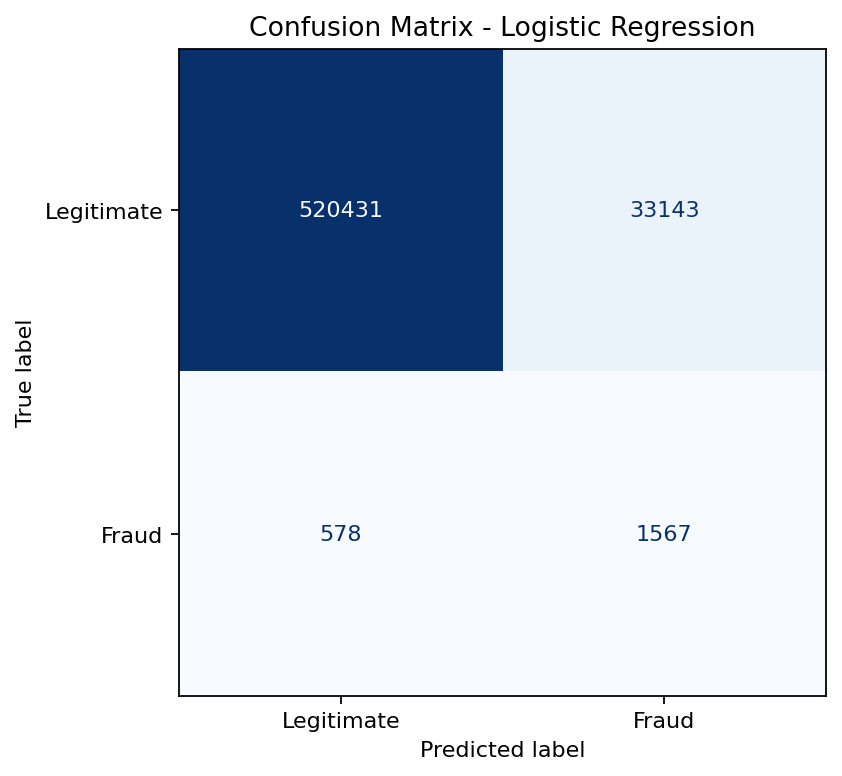

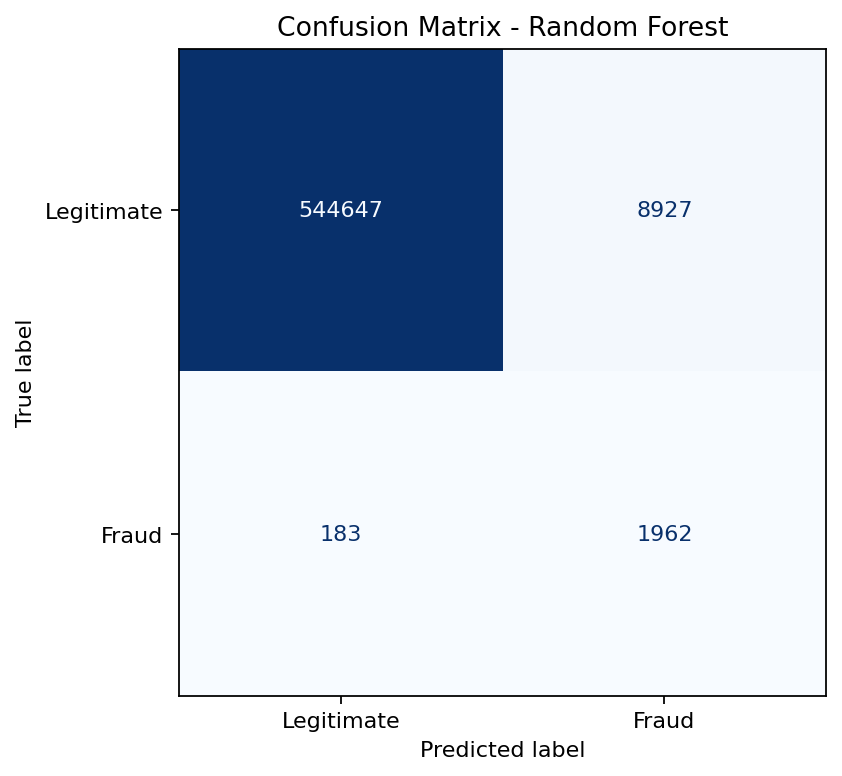

In [4]:
display(Image(filename=str(FIGURE_DIR / "confusion_matrix_logistic_regression.png")))
display(Image(filename=str(FIGURE_DIR / "confusion_matrix_random_forest.png")))


## 5. ROC Curve and Metrics Comparison


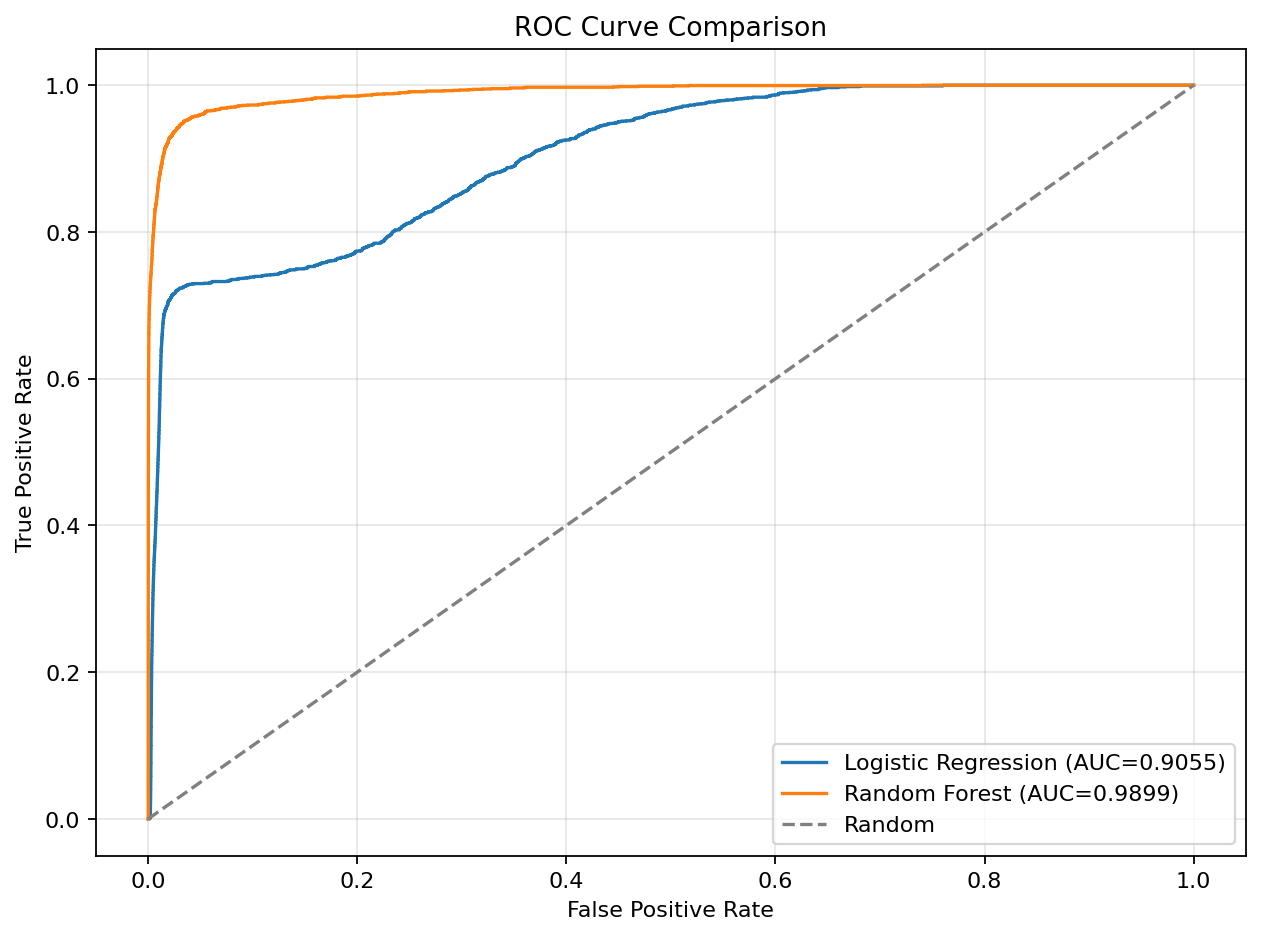

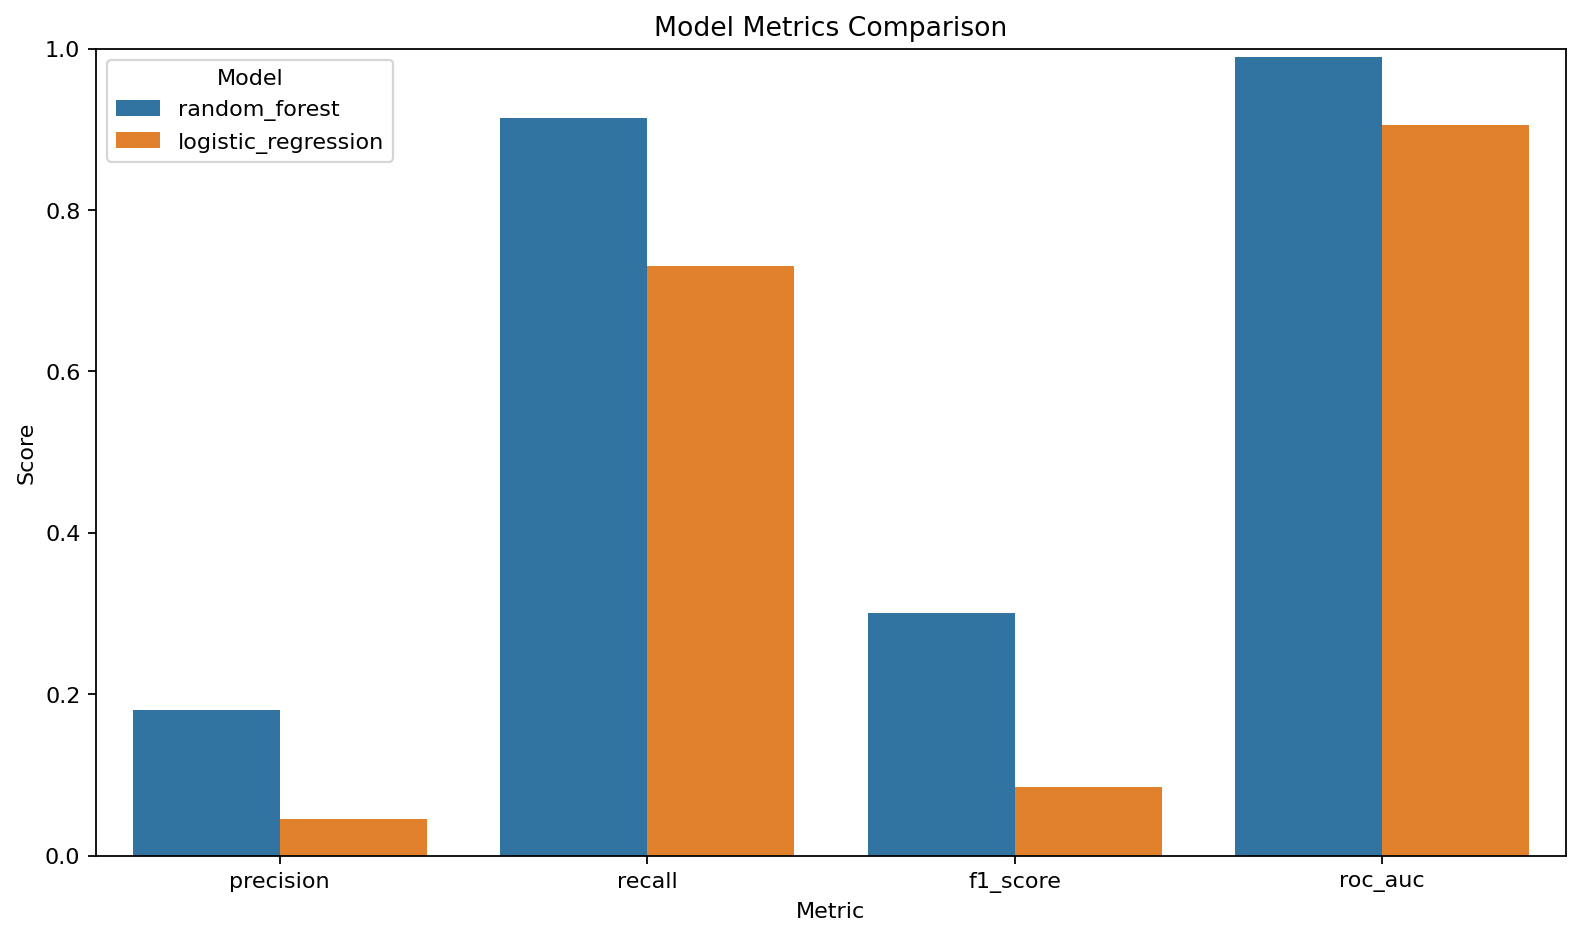

In [5]:
display(Image(filename=str(FIGURE_DIR / "roc_curve_models.png")))
display(Image(filename=str(FIGURE_DIR / "model_metrics_comparison.png")))


## 6. Conclusion

Random Forest cho kết quả tốt hơn Logistic Regression trên test set, đặc biệt ở Recall và ROC-AUC. Với fraud detection, Recall cao giúp giảm số giao dịch gian lận bị bỏ sót. Precision vẫn còn thấp do dữ liệu cực kỳ mất cân bằng, đây là điểm cần cải thiện nếu triển khai thực tế.
